In [1]:
import numpy as np
import matplotlib.pyplot as plt
import batman
from astropy import units as u
from astropy.constants import R_sun, au
from astropy.time import Time
import math
import pandas as pd
import matplotlib.dates as mdates
from datetime import timedelta

### Find the start, mid, and end phase of pre- and post-eclipse

##### Use the mid phase of pre- or post-eclipse as the 'Custom phase' when searching

Mid transit: 0.0
Transit ingress: 0.9785585280286545
Transit egress: 0.02144147197134551
Mid eclipse: 0.5000000000584534
Eclipse ingress: 0.4785585280871078
Eclipse egress: 0.5214414720297988
Pre-eclipse phases:
Start: 0.413218, Mid: 0.443201, End: 0.473185
Post-eclipse phases:
Start: 0.526815, Mid: 0.556799, End: 0.586782


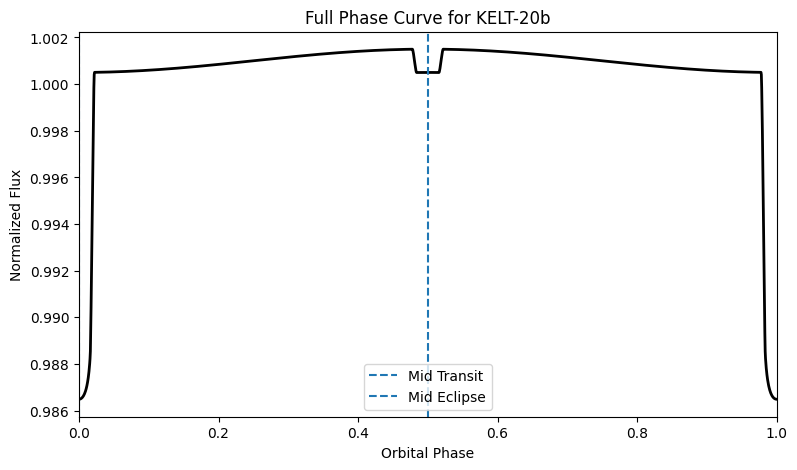

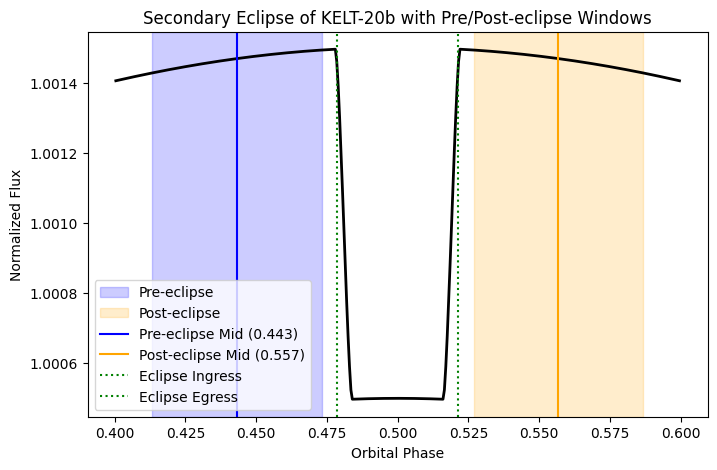

In [38]:
# -----------------------------
# Known parameters (KELT-20b)
# -----------------------------
P = 3.4741085           # Orbital period, days
T_mid = 2459288.807775  # Mid-transit time, BJD
rp_rs = 0.1144          # Planet-to-star radius ratio

# Stellar radius and semi-major axis
R_star = 1.6 * R_sun
a = 0.0542 * u.au
a_rs = (a / R_star).decompose()  # Semi-major axis in stellar radii

inc = 86.12             # Orbital inclination, deg
transit_duration = 0.14898 # Transit duration, days
eclipse_depth = 1000e-6     # Secondary eclipse depth

# -----------------------------
# Known parameters (CoRoT-2b) for check the code --- IGNORE ---
# -----------------------------
# P = 1.742997           # Orbital period of the planet, in days (CoRoT-2b) :contentReference[oaicite:8]{index=8}
# T_mid = 2458363.21037  # Mid-transit time (BJD), from ExoClock :contentReference[oaicite:9]{index=9}
# rp_rs = 0.1667         # Planet-to-star radius ratio :contentReference[oaicite:10]{index=10}

# # Stellar radius and semi-major axis
# R_star = 0.902 * R_sun     # Stellar radius in solar radii :contentReference[oaicite:11]{index=11}
# a = 0.0281 * u.au          # Semi-major axis in AU :contentReference[oaicite:12]{index=12}
# a_rs = (a / R_star).decompose()  # Semi-major axis in stellar radii

# inc = 87.84              # Orbital inclination, in degrees :contentReference[oaicite:13]{index=13}
# transit_duration = 0.095 # Transit duration, in days (~2.28 h) :contentReference[oaicite:14]{index=14}

# # Secondary eclipse depth (approximate; literature suggests a shallow detection)
# eclipse_depth = 60e-6   # Approximate planet-to-star flux ratio during eclipse (dimensionless) :contentReference[oaicite:15]{index=15}


# -----------------------------
# Mid-eclipse and ingress/egress times
# -----------------------------
T_eclipse = T_mid + P/2           # Mid-eclipse time (secondary eclipse), in BJD
t_ingress = T_mid - transit_duration/2  # Start of transit ingress, in BJD
t_egress = T_mid + transit_duration/2   # End of transit egress, in BJD
e_ingress = T_eclipse - transit_duration/2  # Start of eclipse ingress, in BJD
e_egress = T_eclipse + transit_duration/2   # End of eclipse egress, in BJD

print("Mid transit:", to_phase(T_mid))
print("Transit ingress:", to_phase(t_ingress))
print("Transit egress:", to_phase(t_egress))
print("Mid eclipse:", to_phase(T_eclipse))
print("Eclipse ingress:", to_phase(e_ingress))
print("Eclipse egress:", to_phase(e_egress))

# -----------------------------
# Time array and phase
# -----------------------------
t = np.linspace(T_mid - P/2, T_mid + P/2, 2000)
phase = ((t - T_mid) / P) % 1

# -----------------------------
# Phase curve (thermal emission)
# -----------------------------
A = 500e-6
phase_curve = 1 + A * np.cos(2*np.pi*(phase - 0.5))

# -----------------------------
# Transit model
# -----------------------------
params = batman.TransitParams()
params.t0 = T_mid
params.per = P
params.rp = rp_rs
params.a = a_rs
params.inc = inc
params.ecc = 0
params.w = 90
params.limb_dark = "quadratic"
params.u = [0.1,0.3]
m = batman.TransitModel(params, t)
transit_flux = m.light_curve(params)

# -----------------------------
# Eclipse model
# -----------------------------
params2 = batman.TransitParams()
params2.t_secondary = T_eclipse
params2.per = P
params2.rp = rp_rs
params2.a = a_rs
params2.inc = inc
params2.ecc = 0
params2.w = 90
params2.fp = eclipse_depth
params2.limb_dark = "uniform"
params2.u = []
m2 = batman.TransitModel(params2, t, transittype="secondary")
eclipse_flux = m2.light_curve(params2)

# -----------------------------
# Combined flux
# -----------------------------
flux = phase_curve * transit_flux * eclipse_flux

# -----------------------------
# Pre-eclipse and post-eclipse phase calculations
# -----------------------------
# Start, mid, end phases of pre-eclipse
# End of pre-eclipse: just before eclipse ingress
# Mid pre-eclipse: ~2.5 hours earlier
# Start pre-eclipse: ~5 hours earlier

theta = np.arctan(R_star / (2*a))        # Half angular size of star, rad
theta_deg = np.rad2deg(theta)
phase_fraction = (2 * theta_deg / 360).value   # Total transit width in phase units
tolerance = 0.005                        # Small safety margin

# Time offsets in hours
phase_2p5h = 2.5 / (P*24)
phase_5h = 5 / (P*24)

# Pre-eclipse phases
pre_end_phase   = 0.5 - phase_fraction - tolerance
pre_mid_phase   = 0.5 - phase_fraction - phase_2p5h - tolerance
pre_start_phase = 0.5 - phase_fraction - phase_5h - tolerance

# Post-eclipse phases (after secondary eclipse)
post_start_phase = 0.5 + phase_fraction + tolerance
post_mid_phase   = 0.5 + phase_fraction + phase_2p5h + tolerance
post_end_phase   = 0.5 + phase_fraction + phase_5h + tolerance

print("Pre-eclipse phases:")
print(f"Start: {pre_start_phase:.6f}, Mid: {pre_mid_phase:.6f}, End: {pre_end_phase:.6f}")
print("Post-eclipse phases:")
print(f"Start: {post_start_phase:.6f}, Mid: {post_mid_phase:.6f}, End: {post_end_phase:.6f}")

# -----------------------------
# Helper function: convert BJD to orbital phase
# -----------------------------
def to_phase(t_val):
    return ((t_val - T_mid)/P) % 1

# -----------------------------
# Plot full phase curve
# -----------------------------
sort_idx = np.argsort(phase)
phase_sorted = phase[sort_idx]
flux_sorted = flux[sort_idx]

plt.figure(figsize=(9,5))
plt.plot(phase_sorted, flux_sorted, linewidth=2, color='black')
plt.axvline(0, linestyle="--", label="Mid Transit")
plt.axvline(0.5, linestyle="--", label="Mid Eclipse")
plt.xlabel("Orbital Phase")
plt.ylabel("Normalized Flux")
plt.title("Full Phase Curve for KELT-20b")
plt.xlim(0,1)
plt.legend()
plt.show()

# -----------------------------
# Zoom around secondary eclipse with shaded pre/post-eclipse
# -----------------------------
zoom_mask = (phase_sorted >= 0.4) & (phase_sorted <= 0.6)
phase_zoom = phase_sorted[zoom_mask]
flux_zoom = flux_sorted[zoom_mask]

plt.figure(figsize=(8,5))
plt.plot(phase_zoom, flux_zoom, color='black', linewidth=2)

# Shaded regions
plt.axvspan(pre_start_phase, pre_end_phase, color='blue', alpha=0.2, label='Pre-eclipse')
plt.axvspan(post_start_phase, post_end_phase, color='orange', alpha=0.2, label='Post-eclipse')

# Vertical lines for mid points
plt.axvline(pre_mid_phase, linestyle="-", color='blue', label=f"Pre-eclipse Mid ({pre_mid_phase:.3f})")
plt.axvline(post_mid_phase, linestyle="-", color='orange', label=f"Post-eclipse Mid ({post_mid_phase:.3f})")

# Eclipse ingress/egress
plt.axvline(to_phase(e_ingress), linestyle=":", color='green', label="Eclipse Ingress")
plt.axvline(to_phase(e_egress), linestyle=":", color='green', label="Eclipse Egress")

plt.xlabel("Orbital Phase")
plt.ylabel("Normalized Flux")
plt.title("Secondary Eclipse of KELT-20b with Pre/Post-eclipse Windows")
plt.legend()
plt.show()

#### Checking the observation windows for the ±2.5 hr mid-event window around the secondary eclipse (phase 0.5)

NASA exoplanet archive -> transit and enphemeris -> 

Single target (Kelt-20b) -> Get available Ephemerides -> click on the one

Earth observatory (Mauna Kea)

Observing window

Phases (Custom phase: mid phase of pre- or post-eclipse, generated above)

Arrange 'Event midpoint airmass' in increasing order -> download csv -> delete the comments in the csv file

In [70]:
def convert_date(input_date):
    from datetime import datetime

    # Parse the input date string into a datetime object
    datetime_obj = datetime.strptime(input_date, "%m/%d/%Y %H:%M")

    # Convert the datetime object to the desired format
    formatted_date = datetime_obj.strftime("%Y-%m-%dT%H:%M:00.")

    return formatted_date

def format_date_column(input_frame):

    # input: the data of column of interest in the format of dataframe[''] 
    # -> convert the panda dataframe into a list using tolist() 
    # -> convert the number in the list into a list of strings using list(map(str,number_list)) 
    # instead of list comprehension: strings_list = [str(number) for number in numbers]

    format_column = list(map(str,input_frame.tolist()))

    # change the list of strings of date into a correct format using the function created before
    converted_date = [convert_date(date) for date in format_column]
    
    return converted_date

# -----------------------------
# Plot observation windows
# -----------------------------
def plot_observation_windows(midtime, starttime, endtime, airmass, goodness, ncols=3, hours_before=2.5, hours_after=2.5):

    '''
    grey shaded area: full observation window (start to end)
    green shaded area: central ±2.5 hr window around midtime (good)
    red shaded area: central ±2.5 hr window around midtime (bad)

    If the green/red window is entirely inside the grey area, it means the ±2.5 hr mid-event window fits within the available observation time, which is what you want.
    If the green/red window extends outside the grey area, that means your central ±2.5 hr window goes beyond the actual observation window, so only part of it is actually observed.
    '''

    n_obs = len(midtime)
    nrows = int(np.ceil(n_obs / ncols))

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 3*nrows))
    axes = np.array(axes).reshape(-1)  # flatten 2D array

    for i in range(n_obs):
        ax = axes[i]

        # Grey window: full observation
        ax.axvspan(starttime[i].datetime, endtime[i].datetime, color='grey', alpha=0.3)

        # Central ±2.5 hr window around midtime
        window_start = midtime[i].datetime - timedelta(hours=hours_before)
        window_end   = midtime[i].datetime + timedelta(hours=hours_after)
        color = 'green' if goodness[i] else 'red'
        alpha = 0.3 if goodness[i] else 0.1
        ax.axvspan(window_start, window_end, color=color, alpha=alpha)

        # Midtime dashed line
        ax.axvline(midtime[i].datetime, color='black', linestyle='--', lw=2)

        # Title with airmass
        ax.set_title(f"Airmass: {airmass[i]}", fontsize=10)

        # X-axis formatting and showing all labels
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax.tick_params(axis='x', labelrotation=45, labelbottom=True)

    # Remove empty axes
    for j in range(n_obs, nrows*ncols):
        fig.delaxes(axes[j])

    fig.suptitle("Observation Window Evaluation", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [71]:
# # Test the function with the provided input_date
# input_date = "04/11/2023 10:03"
# format_date = convert_date(input_date)

# # Create an Astropy Time object with the input date and specify the input format
# time_object = Time(format_date, format='isot', scale='utc')

# # Convert to Julian Date
# julian_date = time_object.jd

# print(f"Input Date: {input_date}")
# print(f"Formatted Date: {format_date}")
# print(f"Julian Date: {julian_date}")

In [80]:
hours_before = 2.5
hours_after = 2.5

Phase is 0.44
Start times: ['2026-10-02T04:57:00.', '2026-09-25T05:04:00.', '2026-09-18T05:10:00.', '2026-09-11T05:17:00.', '2026-09-04T05:24:00.', '2026-12-14T04:36:00.', '2026-08-28T05:30:00.', '2026-12-07T04:34:00.', '2026-08-21T05:37:00.']
Mid times: ['2026-10-02T05:42:00.', '2026-09-25T06:56:00.', '2026-09-18T08:11:00.', '2026-09-11T09:26:00.', '2026-09-04T10:40:00.', '2026-12-14T04:39:00.', '2026-08-28T11:55:00.', '2026-12-07T05:53:00.', '2026-08-21T13:09:00.']
End times: ['2026-10-02T10:31:00.', '2026-09-25T10:59:00.', '2026-09-18T11:27:00.', '2026-09-11T11:54:00.', '2026-09-04T12:22:00.', '2026-12-14T05:44:00.', '2026-08-28T12:49:00.', '2026-12-07T06:12:00.', '2026-08-21T13:17:00.']
Airmass in increasing order: ['1.02481', '1.06282', '1.14453', '1.28677', '1.52607', '1.81972', '1.94786', '2.52126', '2.79511']


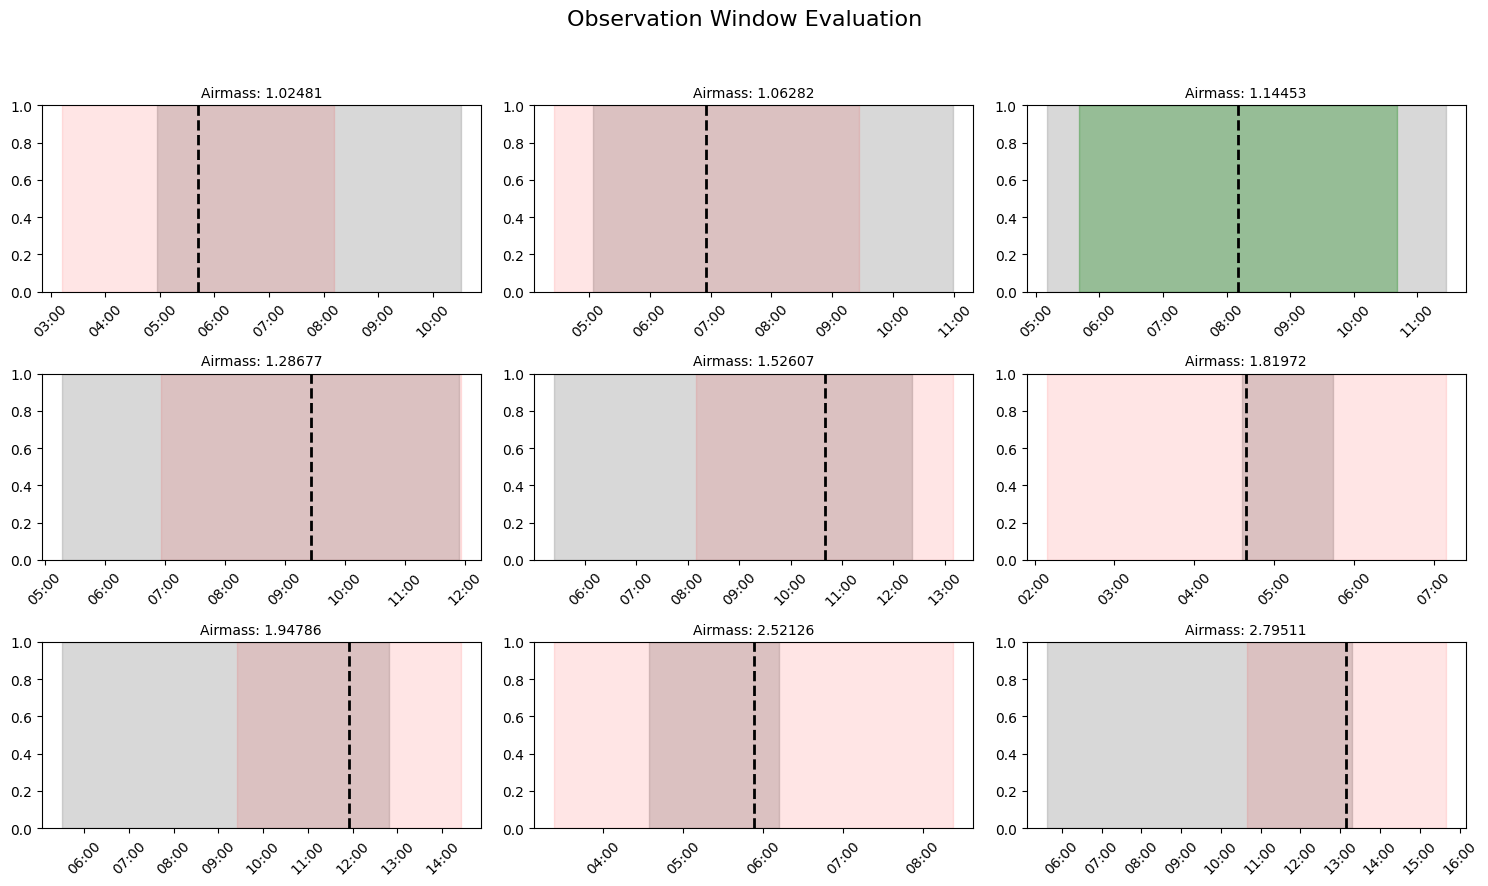

In [85]:
# Read the csv file using pandas: SORTED TABLE IN INCREASING AIRMASS (not date)
# file_path = 'transits_airmass_order.csv' # export the transits table to csv, delete the first 35 irrelevant columns

file_path = 'transits_pre_k20b.csv'
dataframe = pd.read_csv(file_path) 

starttimes = format_date_column(dataframe['targetobsstartcalendar'])
midtimes = format_date_column(dataframe['midpointcalendar'])
endtimes = format_date_column(dataframe['targetobsendcalendar'])

airmass_pre = list(map(str,dataframe['midpointairmass'].tolist()))
phase = dataframe['phase'][0]

print('Phase is', phase)
print(f"Start times: {starttimes}")
print(f"Mid times: {midtimes}")
print(f"End times: {endtimes}")
print(f"Airmass in increasing order: {airmass_pre}")

midt= Time(midtimes, format='isot', scale='utc')
startt= Time(starttimes, format='isot', scale='utc')
endt= Time(endtimes, format='isot', scale='utc')

# in window
goodness = []
for i in range(len(midt)):
    if (startt[i] < midt[i]-hours_before/24 and endt[i] > midt[i]+hours_after/24): # original: 2.4+2.4 = 4.8 hr in total for observation
        # shaded region started from (mid time - 2.5) hr to (mid time + 2.5) hr
        # if change 2.4 (no green) to 2, but WHY?? Logic behind? 
        goodness.append(True)
    else: 
        goodness.append(False)

plot_observation_windows(midt, startt, endt, airmass_pre, goodness, ncols=3, hours_before=hours_before, hours_after=hours_after)


In [86]:
for i in range(len(midt)):
    if (startt[i] < midt[i]-2.5/24):
        windowstart =midt[i]-2.5/24
    else:
        windowstart =startt[i]
    if (endt[i] > midt[i]+2.5/24):
        windowend = midt[i]+2.5/24
    else: 
        windowend = endt[i]
    # window start
    a = str(windowstart.value)
    startstr = a[:10]+' '+a[11:19]
    # duration
    duration = windowend-windowstart
    durstr = '0'+str(np.floor(duration.value*24))[0]+':'+str(round(60*((duration.value*24)%1)))
    print(i, startstr, durstr, airmass_pre[i])

0 2026-10-02 04:57:00 03:15 1.02481
1 2026-09-25 05:04:00 04:22 1.06282
2 2026-09-18 05:41:00 05:0 1.14453
3 2026-09-11 06:56:00 04:58 1.28677
4 2026-09-04 08:10:00 04:12 1.52607
5 2026-12-14 04:36:00 01:8 1.81972
6 2026-08-28 09:25:00 03:24 1.94786
7 2026-12-07 04:34:00 01:38 2.52126
8 2026-08-21 10:39:00 02:38 2.79511


### Post eclipse

Phase is 0.56
Start times: ['2026-09-22T05:06:00.', '2026-09-15T05:13:00.', '2026-09-08T05:20:00.', '2026-09-01T05:26:00.', '2026-08-25T05:33:00.', '2026-08-18T05:39:00.', '2026-11-27T04:32:00.', '2026-08-11T05:45:00.', '2026-11-20T04:32:00.', '2026-08-04T05:49:00.']
Mid times: ['2026-09-22T05:34:00.', '2026-09-15T06:49:00.', '2026-09-08T08:03:00.', '2026-09-01T09:18:00.', '2026-08-25T10:32:00.', '2026-08-18T11:47:00.', '2026-11-27T05:45:00.', '2026-08-11T13:02:00.', '2026-11-20T07:00:00.', '2026-08-04T14:16:00.']
End times: ['2026-09-22T11:11:00.', '2026-09-15T11:38:00.', '2026-09-08T12:06:00.', '2026-09-01T12:33:00.', '2026-08-25T13:01:00.', '2026-08-18T13:28:00.', '2026-11-27T06:51:00.', '2026-08-11T13:56:00.', '2026-11-20T07:19:00.', '2026-08-04T14:23:00.']
Airmass in increasing order: ['1.02361', '1.0248', '1.06277', '1.14442', '1.28659', '1.52578', '1.81926', '1.94731', '2.5203', '2.79392']


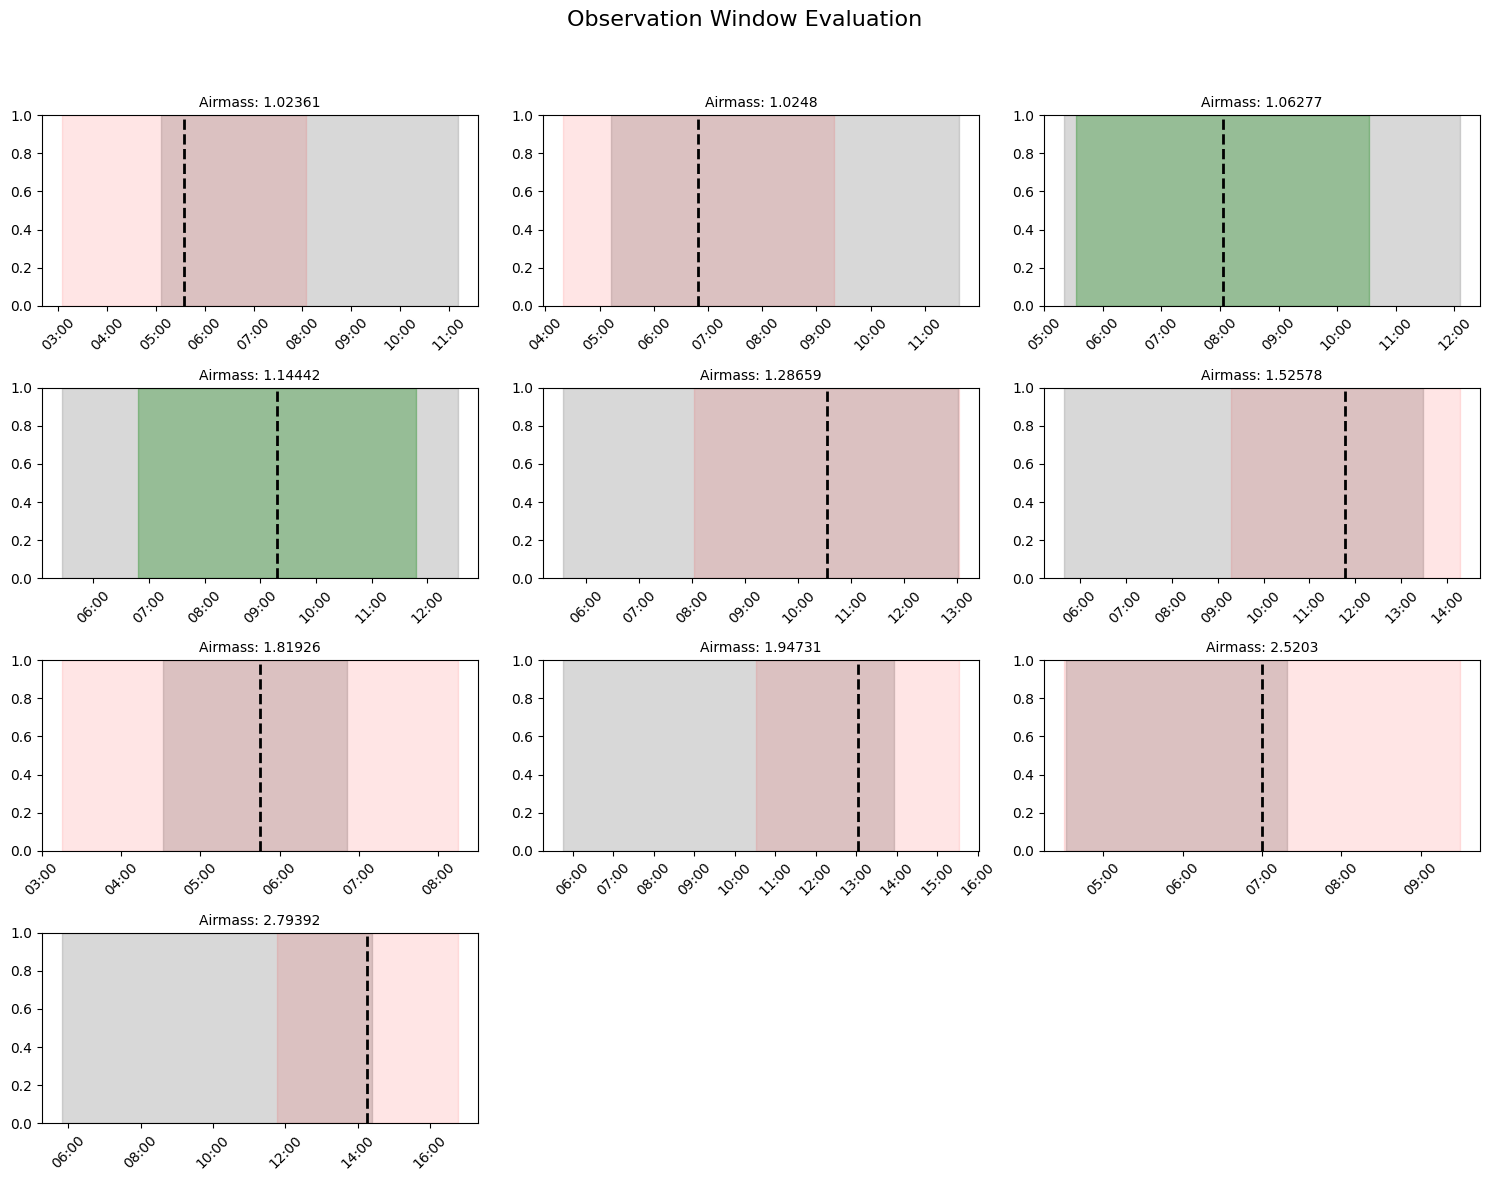

In [83]:
# Read the csv file using pandas: SORTED TABLE IN INCREASING AIRMASS (not date)
# file_path = 'transits_airmass_order.csv' # export the transits table to csv, delete the first 35 irrelevant columns

file_path = 'transits_post_k20b.csv'
dataframe = pd.read_csv(file_path) 

starttimes = format_date_column(dataframe['targetobsstartcalendar'])
midtimes = format_date_column(dataframe['midpointcalendar'])
endtimes = format_date_column(dataframe['targetobsendcalendar'])

airmass_post = list(map(str,dataframe['midpointairmass'].tolist()))
phase = dataframe['phase'][0]

print('Phase is', phase)
print(f"Start times: {starttimes}")
print(f"Mid times: {midtimes}")
print(f"End times: {endtimes}")
print(f"Airmass in increasing order: {airmass_post}")

midt_post= Time(midtimes, format='isot', scale='utc')
startt_post= Time(starttimes, format='isot', scale='utc')
endt_post= Time(endtimes, format='isot', scale='utc')

# in window
goodness = []
for i in range(len(midt_post)):
    if (startt_post[i] < midt_post[i]-hours_before/24 and endt_post[i] > midt_post[i]+hours_after/24): # original: 2.4+2.4 = 4.8 hr in total for observation
        # shaded region started from (mid time - 2.5) hr to (mid time + 2.5) hr
        # if change 2.4 (no green) to 2, but WHY?? Logic behind? 
        goodness.append(True)
    else: 
        goodness.append(False)

plot_observation_windows(midt_post, startt_post, endt_post, airmass_post, goodness, ncols=3, hours_before=hours_before, hours_after=hours_after)


In [87]:
for i in range(len(midt)):
    if (startt_post[i] < midt_post[i]-2.5/24):
        windowstart =midt_post[i]-2.5/24
    else:
        windowstart =startt_post[i]
    if (endt_post[i] > midt_post[i]+2.5/24):
        windowend = midt_post[i]+2.5/24
    else: 
        windowend = endt_post[i]
    # window start
    a = str(windowstart.value)
    startstr = a[:10]+' '+a[11:19]
    # duration
    duration = windowend-windowstart
    durstr = '0'+str(np.floor(duration.value*24))[0]+':'+str(round(60*((duration.value*24)%1)))
    print(i, startstr, durstr, airmass_post[i])

0 2026-09-22 05:06:00 02:58 1.02361
1 2026-09-15 05:13:00 04:6 1.0248
2 2026-09-08 05:33:00 05:0 1.06277
3 2026-09-01 06:48:00 05:0 1.14442
4 2026-08-25 08:02:00 04:59 1.28659
5 2026-08-18 09:17:00 04:11 1.52578
6 2026-11-27 04:32:00 02:19 1.81926
7 2026-08-11 10:32:00 03:24 1.94731
8 2026-11-20 04:32:00 02:47 2.5203
